# Graph representation example

In [1]:
from pymatgen.core import Structure
from pymatgen.analysis.graphs import StructureGraph
from pymatgen.analysis.local_env import CrystalNN
from torch_geometric.data import Data
import torch
import os

# === Step 1: Load structure from file ===
structure_path = "inputs/BiFeO3.cif"  # or .cif
structure = Structure.from_file(structure_path)

# === Step 2: Create StructureGraph using CrystalNN (bond detection) ===
sg = StructureGraph.with_local_env_strategy(structure, CrystalNN())

# === Step 3: Create node features (atomic numbers) ===
node_features = [[site.specie.Z] for site in structure]
x = torch.tensor(node_features, dtype=torch.float)

# === Step 4: Create edge index and edge attributes (bond distances) ===
edge_index = []
edge_attr = []

for i, _ in enumerate(structure):
    neighbors = sg.get_connected_sites(i)
    for neighbor in neighbors:
        j = neighbor.index
        distance = structure[i].distance(neighbor.site)
        edge_index.append([i, j])
        edge_attr.append([distance])

edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
edge_attr = torch.tensor(edge_attr, dtype=torch.float)

# === Step 5: Create PyTorch Geometric graph ===
data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr)

# === Output ===
print(data)



A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "c:\Users\ai2014\Anaconda3\lib\runpy.py", line 197, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "c:\Users\ai2014\Anaconda3\lib\runpy.py", line 87, in _run_code
    exec(code, run_globals)
  File "c:\Users\ai2014\Anaconda3\lib\site-packages\ipykernel_launcher.py", line 16, in <module>
    app.launch_new_instance()
  File "c:\Users\ai2014\Anaconda3\lib\site-packages\traitlets\config\application.py", line 846, in launch_instance
    app.start()
  File "c:\Users\ai2014\Anaconda3\lib\site

AttributeError: _ARRAY_API not found

Data(x=[10, 1], edge_index=[2, 48], edge_attr=[48, 1])


C:\Users\ai2014\AppData\Local\Temp\ipykernel_13404\1942196690.py:13: FutureWarning: with_local_env_strategy is deprecated, and will be removed on 2025-03-20
Use from_local_env_strategy in pymatgen.analysis.graphs instead.
Deprecated on 2024-03-29.
  sg = StructureGraph.with_local_env_strategy(structure, CrystalNN())
c:\Users\ai2014\Anaconda3\lib\site-packages\pymatgen\analysis\local_env.py:4151: UserWarning: No oxidation states specified on sites! For better results, set the site oxidation states in the structure.
  warnings.warn(
c:\Users\ai2014\Anaconda3\lib\site-packages\pymatgen\analysis\local_env.py:3944: UserWarning: CrystalNN: cannot locate an appropriate radius, covalent or atomic radii will be used, this can lead to non-optimal results.
  warnings.warn(


C:\Users\ai2014\AppData\Local\Temp\ipykernel_13404\1448486945.py:10: FutureWarning: with_local_env_strategy is deprecated, and will be removed on 2025-03-20
Use from_local_env_strategy in pymatgen.analysis.graphs instead.
Deprecated on 2024-03-29.
  sg = StructureGraph.with_local_env_strategy(structure, CrystalNN())
c:\Users\ai2014\Anaconda3\lib\site-packages\pymatgen\analysis\local_env.py:4151: UserWarning: No oxidation states specified on sites! For better results, set the site oxidation states in the structure.
  warnings.warn(
c:\Users\ai2014\Anaconda3\lib\site-packages\pymatgen\analysis\local_env.py:3944: UserWarning: CrystalNN: cannot locate an appropriate radius, covalent or atomic radii will be used, this can lead to non-optimal results.
  warnings.warn(


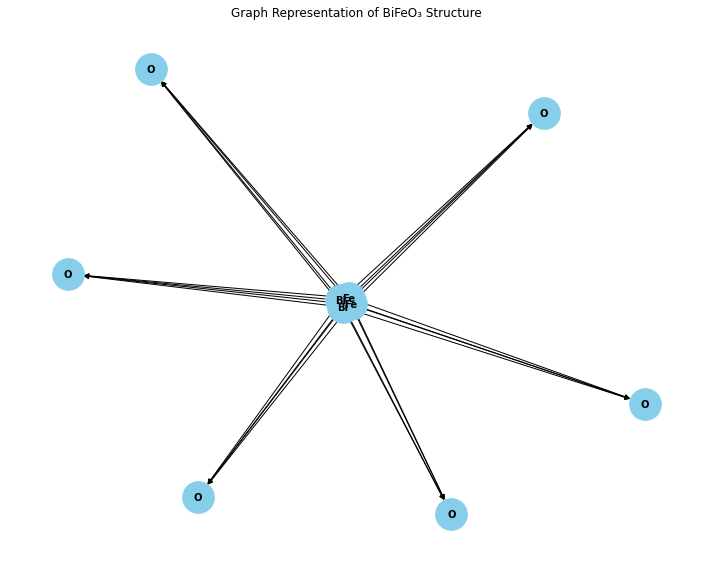

In [2]:
import matplotlib.pyplot as plt
import networkx as nx
from pymatgen.core import Structure
from pymatgen.analysis.graphs import StructureGraph
from pymatgen.analysis.local_env import CrystalNN

structure = Structure.from_file("inputs/BiFeO3.cif")

# Create a StructureGraph using CrystalNN
sg = StructureGraph.with_local_env_strategy(structure, CrystalNN())

G = sg.graph

pos = nx.spring_layout(G, seed=42)

labels = {i: site.specie.symbol for i, site in enumerate(structure)}


fig, ax = plt.subplots(figsize=(10, 8))

nx.draw(G, pos, labels=labels, with_labels=True,
        node_color='skyblue', node_size=1000,
        font_size=10, font_weight='bold', ax=ax)
plt.title("Graph Representation of BiFeO₃ Structure")
plt.axis('off')  # Turn off the axis
plt.tight_layout()  # Apply tight layout to the entire figure
plt.show()


C:\Users\ai2014\AppData\Local\Temp\ipykernel_20540\3542443412.py:12: FutureWarning: get_structures is deprecated; use parse_structures in pymatgen.io.cif instead.
The only difference is that primitive defaults to False in the new parse_structures method.So parse_structures(primitive=True) is equivalent to the old behavior of get_structures().
  structure = parser.get_structures()[0]


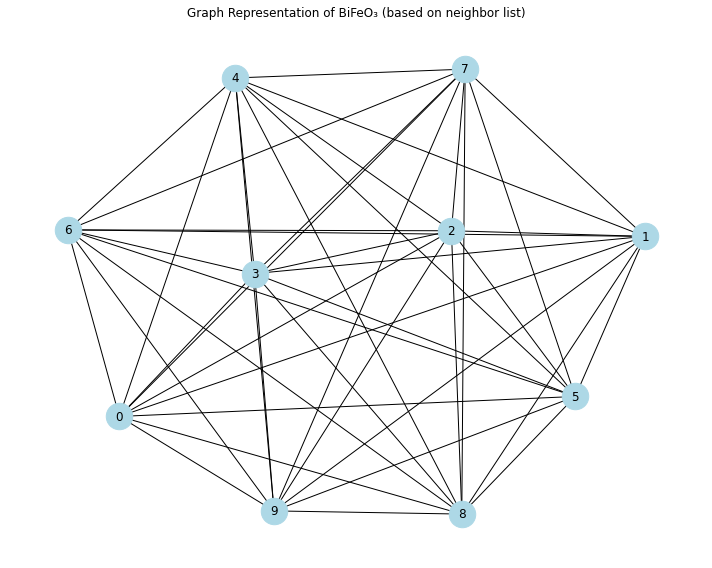

In [ ]:
from pymatgen.io.cif import CifParser
from pymatgen.io.ase import AseAtomsAdaptor
from ase.neighborlist import neighbor_list
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import torch

# Load BiFeO3 structure from CIF file
parser = CifParser("inputs/BiFeO3.cif")
structure = parser.get_structures()[0]

# One-hot encoding of atomic number
def one_hot_encode_z(atomic_number: int):
    vector = np.zeros(118)
    vector[atomic_number - 1] = 1
    return vector

# Generate node features using one-hot encoding
node_features = torch.tensor([one_hot_encode_z(site.specie.Z) for site in structure])

# ASE atoms object from pymatgen structure
atoms = AseAtomsAdaptor.get_atoms(structure)

# Define cutoff radius for neighbors
cutoff_radius = 4.0  # Angstrom

# Generate edge list using ASE neighbor list
edge_src, edge_dst, edge_len = neighbor_list("ijd", atoms, cutoff=cutoff_radius, self_interaction=False)

color_map = {"Bi": "orange", "Fe": "red", "O": "lightblue"}

G = nx.Graph()
for i, site in enumerate(structure.sites):
    G.add_node(i, element=site.species_string)  # Add 'element' attribute to nodes

for s1, s2 in zip(edge_src, edge_dst):
    G.add_edge(s1, s2)

labels = {i: G.nodes[i]["element"] for i in G.nodes}
colors = [color_map[G.nodes[i]["element"]] for i in G.nodes]
pos = nx.spring_layout(G, seed=42)

fig, ax = plt.subplots(figsize=(10, 8))

nx.draw(G, with_labels=True, node_color='lightblue', node_size=700, font_size=12, ax=ax)
plt.title("Graph Representation of BiFeO₃ (based on neighbor list)")
plt.axis('off')  # Correct usage of plt.axis
plt.tight_layout()
plt.show()


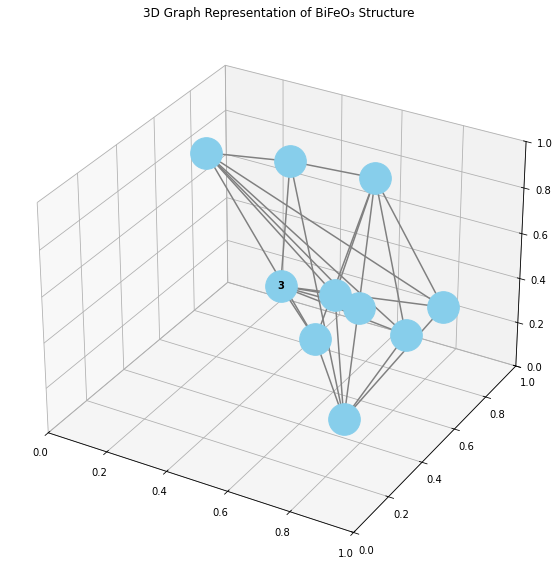

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import networkx as nx
from mpl_toolkits.mplot3d import Axes3D

# Create a 3D plot
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Generate positions in 3D for the graph
pos_3d = {node: np.random.rand(3) for node in G.nodes}  # Random 3D positions, replace with your structure's positions

# Draw the 3D graph manually
for edge in G.edges():
    x_coords = [pos_3d[edge[0]][0], pos_3d[edge[1]][0]]
    y_coords = [pos_3d[edge[0]][1], pos_3d[edge[1]][1]]
    z_coords = [pos_3d[edge[0]][2], pos_3d[edge[1]][2]]
    ax.plot(x_coords, y_coords, z_coords, color='gray')

# Draw the nodes
for node, (x, y, z) in pos_3d.items():
    ax.scatter(x, y, z, color='skyblue', s=1000)
    ax.text(x, y, z, str(node), fontsize=10, fontweight='bold', ha='center', va='center')

# Set title and axis limits
ax.set_title("3D Graph Representation of BiFeO₃ Structure")
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
ax.set_zlim([0, 1])

plt.show()


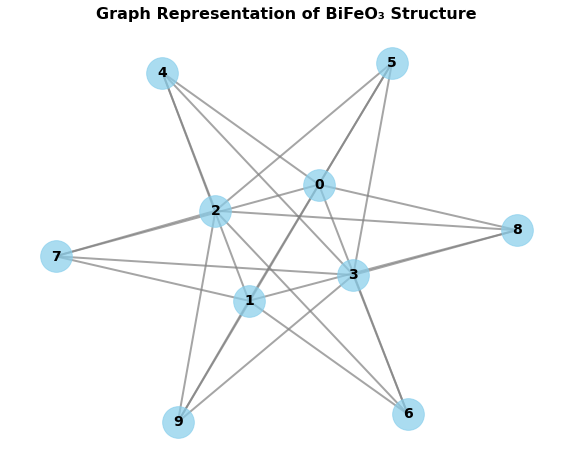

In [5]:
import matplotlib.pyplot as plt
import networkx as nx

# Extract edge_src and edge_dst from edge_index
edge_src, edge_dst = edge_index[0].tolist(), edge_index[1].tolist()

# Create a graph and add edges
G = nx.Graph()
for s1, s2 in zip(edge_src, edge_dst):
    G.add_edge(s1, s2)

# Apply a spring layout for better node placement
pos = nx.spring_layout(G, seed=42)  # Adjust the seed for reproducibility

# Draw the graph with custom styling
plt.figure(figsize=(10, 8))

# Draw nodes with better customization
nx.draw_networkx_nodes(G, pos, node_size=1000, node_color='skyblue', alpha=0.7)

# Draw edges with customized colors
nx.draw_networkx_edges(G, pos, width=2, edge_color='gray', alpha=0.7)

# Draw labels with better font size and styling
nx.draw_networkx_labels(G, pos, font_size=14, font_color='black', font_weight='bold')

# Set title and remove axis for a cleaner look
plt.title("Graph Representation of BiFeO₃ Structure", fontsize=16, fontweight='bold')
plt.axis('off')  # Hide axes for a cleaner visual

# Show the plot
plt.show()


In [6]:
from pymatgen.core import Structure
from pymatgen.analysis.local_env import CrystalNN
import torch
import torch.nn as nn
import torch.nn.functional as F 
from torch_geometric.data import Data


In [7]:

structure = Structure.from_file("inputs/BiFeO3.cif")


In [8]:
x = torch.tensor([[site.specie.Z] for site in structure], dtype=torch.float)


In [9]:
data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr)

print(data)


Data(x=[10, 1], edge_index=[2, 48], edge_attr=[48, 1])


In [11]:
G = nx.Graph()
for s1, s2 in zip(edge_src, edge_dst):
    G.add_edge(s1, s2)

# Ensure plt.show() is used correctly
nx.draw(G, with_labels=True, node_color='lightblue', node_size=700, font_size=12)
plt.show()

TypeError: '_AxesStack' object is not callable

<Figure size 432x288 with 0 Axes>

In [12]:
nn_finder = CrystalNN()
edges = []
edge_attr = []

for i, site in enumerate(structure):
    neighbors = nn_finder.get_nn_info(structure, i)
    for n in neighbors:
        j = n['site_index']
        dist = site.distance(n['site'])
        edges.append((i, j))
        edge_attr.append([dist])  # you can add more features here


In [13]:
# Remove duplicate edges (optional, useful if undirected)
edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
edge_attr = torch.tensor(edge_attr, dtype=torch.float)


# Graph theory

1. Atoms become nodes
   
Every atom in a material is treated as a node in a graph.

Each node carries features — in our case, a one-hot encoded vector of length 118 (to represent all elements in the periodic table).

In [14]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from pymatgen.io.ase import AseAtomsAdaptor
from ase.neighborlist import neighbor_list
from matminer.data_retrieval.retrieve_MP import MPDataRetrieval

class ExampleClass:
	def __init__(self, embedding):
		self.embedding = embedding

	def process_batch(self, batch):
		# Ensure `batch` has a `node_feat` attribute
		node_feat = self.embedding(batch.node_feat)
		return node_feat

# Example usage
# Assuming `embedding` is a valid PyTorch module and `batch` is an object with a `node_feat` attribute
embedding = torch.nn.Linear(10, 5)  # Example embedding layer
example_instance = ExampleClass(embedding)

# Create a dummy batch with a `node_feat` attribute for demonstration
class DummyBatch:
	def __init__(self, node_feat):
		self.node_feat = node_feat

batch = DummyBatch(torch.randn(10, 10))  # Example batch with random node features

# Process the batch
result = example_instance.process_batch(batch)
print(result)




A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "c:\Users\ai2014\Anaconda3\lib\runpy.py", line 197, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "c:\Users\ai2014\Anaconda3\lib\runpy.py", line 87, in _run_code
    exec(code, run_globals)
  File "c:\Users\ai2014\Anaconda3\lib\site-packages\ipykernel_launcher.py", line 16, in <module>
    app.launch_new_instance()
  File "c:\Users\ai2014\Anaconda3\lib\site-packages\traitlets\config\application.py", line 846, in launch_instance
    app.start()
  File "c:\Users\ai2014\Anaconda3\lib\site

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "c:\Users\ai2014\Anaconda3\lib\runpy.py", line 197, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "c:\Users\ai2014\Anaconda3\lib\runpy.py", line 87, in _run_code
    exec(code, run_globals)
  File "c:\Users\ai2014\Anaconda3\lib\site-packages\ipykernel_launcher.py", line 16, in <module>
    app.launch_new_instance()
  File "c:\Users\ai2014\Anaconda3\lib\site-packages\traitlets\config\application.py", line 846, in launch_instance
    app.start()
  File "c:\Users\ai2014\Anaconda3\lib\site

AttributeError: _ARRAY_API not found

tensor([[ 0.1012,  0.4395, -0.2739, -0.2807, -0.0315],
        [-0.9423,  0.0174,  1.4336, -0.8310, -1.6858],
        [ 0.0814,  0.6725, -0.9117,  0.9980, -0.3188],
        [ 0.3854,  0.2014, -0.9774,  0.0133,  0.1605],
        [-1.1815, -0.0109, -0.1720, -0.4601, -0.4830],
        [ 0.8217,  0.5638, -0.5611,  0.3184, -0.1456],
        [-0.0050, -0.2981,  0.3690,  0.6878,  0.0593],
        [-0.0595, -1.2715,  0.4121,  0.1577,  0.0188],
        [ 0.0550,  0.4805, -0.1992, -0.2095, -0.9784],
        [-0.5499,  0.7875, -0.1088, -0.8906,  0.3445]],
       grad_fn=<AddmmBackward0>)


2. Edges connect neighboring atoms
We define an edge between two atoms if they’re within a cutoff distance (e.g., 4 Ångströms).

These edges represent bonds or neighbor relationships.

In [ ]:
from pymatgen.core import Structure
from pymatgen.io.ase import AseAtomsAdaptor

# Load the structure from the CIF file
atoms = AseAtomsAdaptor.get_atoms(Structure.from_file('inputs/BiFeO3.cif'))
structure = AseAtomsAdaptor.get_structure(atoms)
atoms = AseAtomsAdaptor.get_atoms(structure)  # Use the actual structure object
cutoff_radius = 5.0  # Define your cutoff radius here


# Get the neighbor list
edge_src, edge_dst, edge_len = neighbor_list(
    "ijd", atoms, cutoff=cutoff_radius, self_interaction=False
)
edge_index = torch.tensor([edge_src, edge_dst], dtype=torch.long)


3. Edges store bond-length information
Each edge also has a feature: the bond length.

To make this more useful for the model, we map the bond length into a Gaussian basis — essentially turning a single number into a fixed-size vector.

In [ ]:
cutoff_radius = 5.0  # Example cutoff radius, adjust as needed
number_of_gaussians = 80  # Example number of Gaussian functions, adjust as needed

In [ ]:
# one hot encode bond length using gaussians.
filter = np.linspace(0, cutoff_radius, number_of_gaussians)
edge_feat = np.exp(
    -((edge_len[..., None] - filter) ** 2) / (filter[1] - filter[0]) ** 2
)
edge_feat = torch.tensor(edge_feat, dtype=torch.float)


4. Each material becomes a graph object
We combine node features, edge indices, edge features, and the target property into a torch_geometric.data.Data object.

This object represents a full graph (i.e. one material).

In [ ]:
from torch_geometric.data import Data

data = Data(
    x=node_features,
    edge_index=edge_index,
    edge_attr=edge_feat,
    y=target
)


NameError: name 'target' is not defined

5. Neighborhoods drive learning (message passing)
During training, each node (atom) receives messages from its neighbors and updates itself.

This is implemented using layers like GCNConv, which aggregate neighbor information.

In [ ]:
from torch_geometric.nn import GCNConv  # Import GCNConv

# Ensure SimpleGNN is defined
class SimpleGNN(torch.nn.Module):
	def __init__(self, in_node_features, hidden_channels, out_channels):
		super(SimpleGNN, self).__init__()
		# Define two simple graph convolutional layers
		self.conv1 = GCNConv(in_node_features, hidden_channels)
		self.conv2 = GCNConv(hidden_channels, hidden_channels)
		#
		self.linear = torch.nn.Linear(hidden_channels, out_channels)  # Direct graph-level prediction

	def forward(self, x, edge_index):
		x = self.conv1(x, edge_index)  # First GCN layer
		x = F.relu(x)  # Apply non-linearity
		x = self.conv2(x, edge_index)  # Second GCN layer
		#
		x = F.relu(x)
		# Instead of pooling, use the entire graph embedding
		x = self.linear(x.mean(dim=0))  # Generate graph-level output directly (no pooling)
		return x

# Define the model as an instance of the SimpleGNN class
in_node_features = x.shape[1]  # Number of input node features
hidden_channels = 64  # Example hidden channel size
out_channels = 1  # Example output channel size
model = SimpleGNN(in_node_features, hidden_channels, out_channels)

# Use the model
x = model.conv1(x, edge_index)
x = F.relu(x)


IndexError: tuple index out of range

6. Graph pooling summarizes the full material
   
After atoms communicate, we pool their information into a single vector that represents the whole material — necessary for predicting a graph-level property like formation energy.


In [ ]:
from torch_geometric.nn import global_mean_pool

# Ensure `batch` is defined as a tensor indicating the batch assignment of each node
batch = torch.zeros(x.size(0), dtype=torch.long)  # Example: all nodes belong to batch 0

x = global_mean_pool(x, batch)  # Perform global mean pooling

# Define a linear layer explicitly
linear_layer = torch.nn.Linear(x.size(1), out_channels)  # Replace `out_channels` with the desired output size
out = linear_layer(x)  # Pass the pooled features through the linear layer


TypeError: 'int' object is not callable

C:\Users\ai2014\AppData\Local\Temp\ipykernel_13404\2693785937.py:11: FutureWarning: get_structures is deprecated; use parse_structures in pymatgen.io.cif instead.
The only difference is that primitive defaults to False in the new parse_structures method.So parse_structures(primitive=True) is equivalent to the old behavior of get_structures().
  structure = parser.get_structures()[0]
C:\Users\ai2014\AppData\Local\Temp\ipykernel_13404\2693785937.py:20: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:257.)
  node_features = torch.tensor([one_hot_encode_z(site.specie.Z) for site in structure])


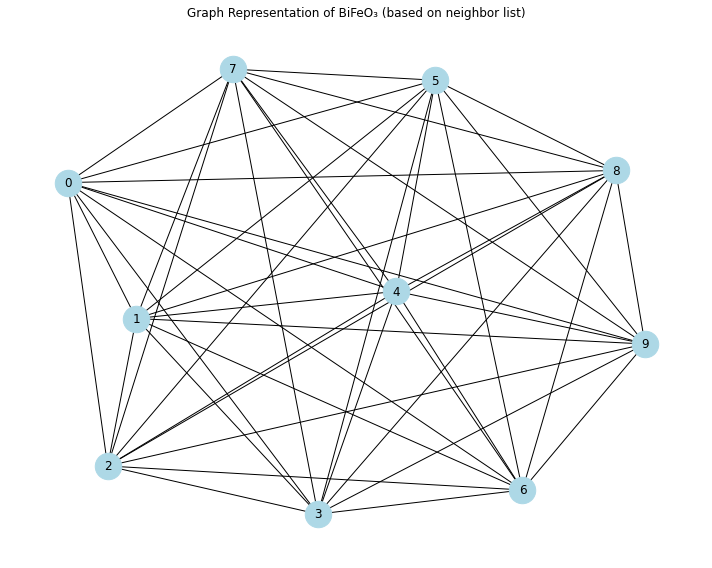

In [15]:
from pymatgen.io.cif import CifParser
from pymatgen.io.ase import AseAtomsAdaptor
from ase.neighborlist import neighbor_list
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import torch

# Load BiFeO3 structure from CIF file
parser = CifParser("inputs/BiFeO3.cif")
structure = parser.get_structures()[0]

# One-hot encoding of atomic number
def one_hot_encode_z(atomic_number: int):
    vector = np.zeros(118)
    vector[atomic_number - 1] = 1
    return vector

# Generate node features using one-hot encoding
node_features = torch.tensor([one_hot_encode_z(site.specie.Z) for site in structure])

# ASE atoms object from pymatgen structure
atoms = AseAtomsAdaptor.get_atoms(structure)

# Define cutoff radius for neighbors
cutoff_radius = 4.0  # Angstrom

# Generate edge list using ASE neighbor list
edge_src, edge_dst, edge_len = neighbor_list("ijd", atoms, cutoff=cutoff_radius, self_interaction=False)

color_map = {"Bi": "orange", "Fe": "red", "O": "lightblue"}

G = nx.Graph()
for i, site in enumerate(structure.sites):
    G.add_node(i, element=site.species_string)  # Add 'element' attribute to nodes

for s1, s2 in zip(edge_src, edge_dst):
    G.add_edge(s1, s2)

labels = {i: G.nodes[i]["element"] for i in G.nodes}
colors = [color_map[G.nodes[i]["element"]] for i in G.nodes]
pos = nx.spring_layout(G, seed=42)

fig, ax = plt.subplots(figsize=(10, 8))

nx.draw(G, with_labels=True, node_color='lightblue', node_size=700, font_size=12, ax=ax)
plt.title("Graph Representation of BiFeO₃ (based on neighbor list)")
plt.axis('off')  # Correct usage of plt.axis
plt.tight_layout()
plt.show()


C:\Users\ai2014\AppData\Local\Temp\ipykernel_13404\2140506097.py:7: FutureWarning: get_structures is deprecated; use parse_structures in pymatgen.io.cif instead.
The only difference is that primitive defaults to False in the new parse_structures method.So parse_structures(primitive=True) is equivalent to the old behavior of get_structures().
  structure = parser.get_structures()[0]


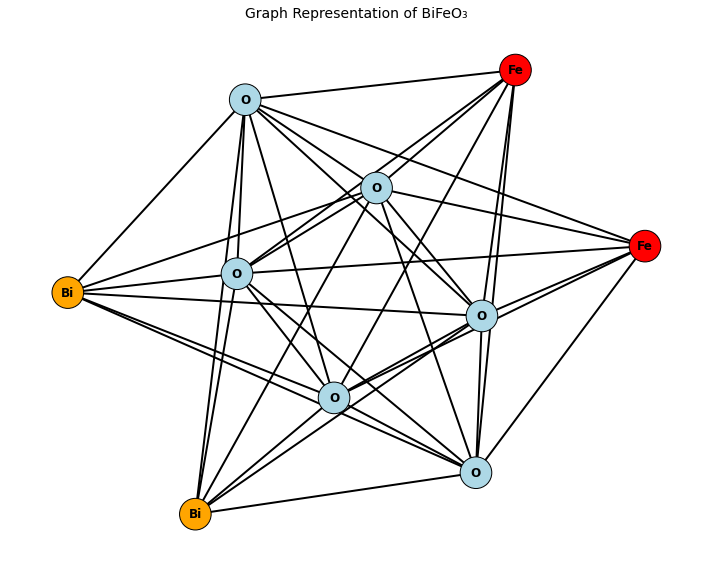

In [16]:
import networkx as nx
import matplotlib.pyplot as plt
from pymatgen.io.cif import CifParser

# Parse BiFeO₃ structure
parser = CifParser("inputs/BiFeO3.cif")  # Ensure the correct file name and path
structure = parser.get_structures()[0]

# Define colors for atom types
color_map = {"Bi": "orange", "Fe": "red", "O": "lightblue"}

# Build graph
G = nx.Graph()
for i, site in enumerate(structure.sites):
    G.add_node(i, element=site.species_string)

cutoff = 3.0
for i, site in enumerate(structure.sites):
    neighbors = structure.get_neighbors(site, cutoff)
    for neighbor in neighbors:
        j = neighbor.index  # Use the index attribute of PeriodicNeighbor
        if i < j:
            G.add_edge(i, j)

# Create layout
labels = {i: G.nodes[i]["element"] for i in G.nodes}
colors = [color_map[G.nodes[i]["element"]] for i in G.nodes]
pos = nx.spring_layout(G, seed=42)

# Draw graph with colors and labels
plt.figure(figsize=(10, 8))
nx.draw_networkx_nodes(G, pos, node_color=colors, edgecolors='black', node_size=1000)
nx.draw_networkx_edges(G, pos, width=2)
nx.draw_networkx_labels(G, pos, labels, font_size=12, font_weight="bold")
plt.title("Graph Representation of BiFeO₃", fontsize=14)
plt.axis("off")
plt.tight_layout()
plt.show()
